# Throw Completion % Model

Predicts P(completion | thrower, from_position, to_position).

**Features:**
- `from_x`, `from_y` — direction-normalized thrower position
- `to_x`, `to_y` — direction-normalized target position
- `dist` — Euclidean distance of throw
- `dy` — `to_y - from_y` (upfield positive)
- `dx` — `to_x - from_x` (lateral)
- `angle` — `atan2(dy, dx)` in radians
- `thrower_encoded` — LabelEncoder on thrower name

**Label:** 1 if event_type IN (18, 19), 0 if event_type IN (20, 22)

**Model:** XGBoost

In [10]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
import joblib
import os
import matplotlib.pyplot as plt

In [11]:
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

conn = psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)
cur = conn.cursor()

cur.execute("""
    SELECT
        e.thrower,
        CASE WHEN e.team = g.away_team_id THEN -e.thrower_x   ELSE e.thrower_x   END AS from_x,
        CASE WHEN e.team = g.away_team_id THEN 120-e.thrower_y ELSE e.thrower_y   END AS from_y,
        CASE WHEN e.event_type IN (18,19)
             THEN (CASE WHEN e.team = g.away_team_id THEN -e.receiver_x   ELSE e.receiver_x   END)
             ELSE (CASE WHEN e.team = g.away_team_id THEN -e.turnover_x   ELSE e.turnover_x   END)
        END AS to_x,
        CASE WHEN e.event_type IN (18,19)
             THEN (CASE WHEN e.team = g.away_team_id THEN 120-e.receiver_y ELSE e.receiver_y   END)
             ELSE (CASE WHEN e.team = g.away_team_id THEN 120-e.turnover_y ELSE e.turnover_y   END)
        END AS to_y,
        CASE WHEN e.event_type IN (18,19) THEN 1 ELSE 0 END AS completed
    FROM events e JOIN games g ON e.game_id = g.game_id
    WHERE e.event_type IN (18,19,20,22) AND e.thrower IS NOT NULL AND e.thrower_x IS NOT NULL
      AND ((e.event_type IN (18,19) AND e.receiver_x IS NOT NULL)
        OR (e.event_type IN (20,22) AND e.turnover_x IS NOT NULL))
""")

rows = cur.fetchall()
cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f'Total throw events: {len(df):,}')
print(f'Completion rate: {df["completed"].mean():.3f}')
print(f'Unique throwers: {df["thrower"].nunique()}')
print(f'\nEvent type distribution:')
print(df['completed'].value_counts())

Total throw events: 407,902
Completion rate: 0.941
Unique throwers: 1820

Event type distribution:
completed
1    383897
0     24005
Name: count, dtype: int64


In [12]:
# Compute derived features
df['dy'] = df['to_y'] - df['from_y']
df['dx'] = df['to_x'] - df['from_x']
df['dist'] = np.sqrt(df['dx']**2 + df['dy']**2)
df['angle'] = np.arctan2(df['dy'], df['dx'])

# Encode thrower
le = LabelEncoder()
df['thrower_encoded'] = le.fit_transform(df['thrower'])

print(f'Thrower encoder classes: {len(le.classes_)}')
print(f'\nFeature stats:')
print(df[['from_x','from_y','to_x','to_y','dist','dy','dx','angle']].describe().round(2))

Thrower encoder classes: 1820

Feature stats:
          from_x     from_y       to_x       to_y       dist         dy  \
count  407902.00  407902.00  407902.00  407902.00  407902.00  407902.00   
mean        0.39      51.19       0.45      59.43      16.67       8.24   
std        12.87      23.44      13.01      26.30      11.38      14.15   
min       -26.67       0.00     -26.67       0.00       0.00     -75.68   
25%        -9.69      32.40     -10.03      38.12      10.14      -0.28   
50%         0.27      49.51       0.43      57.13      13.85       6.48   
75%        10.62      70.21      11.07      79.22      18.84      12.96   
max        26.66     100.00      26.66     120.00     107.62     107.45   

              dx      angle  
count  407902.00  407902.00  
mean        0.05       0.74  
std        11.80       1.66  
min       -51.88      -3.14  
25%        -8.84      -0.05  
50%         0.29       1.08  
75%         8.76       1.94  
max        52.91       3.14  


In [13]:
FEATURE_COLS = ['from_x', 'from_y', 'to_x', 'to_y', 'dist', 'dy', 'dx', 'angle', 'thrower_encoded']

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['completed'].values.astype(np.float32)

print(f'Feature matrix: {X.shape}')
print(f'Label distribution: {y.mean():.3f} completion rate')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Feature matrix: (407902, 9)
Label distribution: 0.941 completion rate
Train: 326,321 | Test: 81,581


## Train XGBoost

In [14]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

pred = xgb_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)
brier = brier_score_loss(y_test, pred)

print(f'\nXGBoost AUC-ROC: {auc:.4f}')
print(f'XGBoost Brier Score: {brier:.4f}')

[0]	validation_0-auc:0.76917
[50]	validation_0-auc:0.80903
[100]	validation_0-auc:0.81347
[150]	validation_0-auc:0.81510
[200]	validation_0-auc:0.81596
[250]	validation_0-auc:0.81645
[299]	validation_0-auc:0.81690

XGBoost AUC-ROC: 0.8169
XGBoost Brier Score: 0.0461


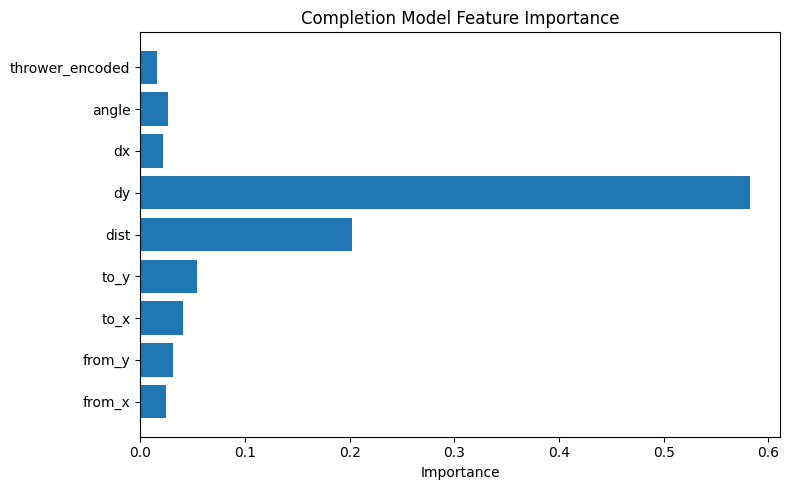

  dy: 0.5820
  dist: 0.2025
  to_y: 0.0541
  to_x: 0.0411
  from_y: 0.0314
  angle: 0.0266
  from_x: 0.0246
  dx: 0.0221
  thrower_encoded: 0.0156


In [15]:
# Feature importance
importance = xgb_model.feature_importances_
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(FEATURE_COLS, importance)
ax.set_title('Completion Model Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

for col, imp in sorted(zip(FEATURE_COLS, importance), key=lambda x: -x[1]):
    print(f'  {col}: {imp:.4f}')

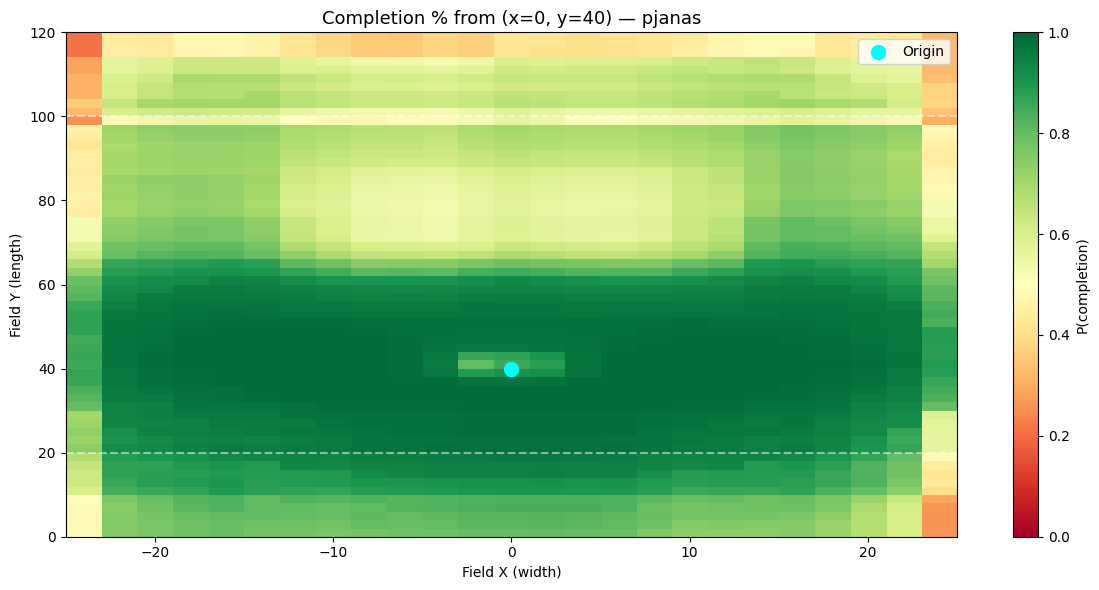

In [16]:
# Visualize completion heatmap from midfield for a specific thrower
def make_completion_grid(from_x=0, from_y=40, thrower_name=None):
    xs = np.linspace(-25, 25, 25)
    ys = np.linspace(0, 120, 60)
    xx, yy = np.meshgrid(xs, ys)  # shape (60, 25)

    if thrower_name and thrower_name in le.classes_:
        thrower_enc = le.transform([thrower_name])[0]
    else:
        thrower_enc = 0

    to_x = xx.ravel()
    to_y = yy.ravel()
    dy = to_y - from_y
    dx = to_x - from_x
    dist = np.sqrt(dx**2 + dy**2)
    angle = np.arctan2(dy, dx)

    grid_points = np.column_stack([
        np.full(xx.size, from_x),
        np.full(xx.size, from_y),
        to_x, to_y,
        dist, dy, dx, angle,
        np.full(xx.size, thrower_enc),
    ]).astype(np.float32)

    probs = xgb_model.predict_proba(grid_points)[:, 1]
    return probs.reshape(60, 25)

# Sample thrower — pick the one with most throws
top_thrower = df.groupby('thrower').size().idxmax()
grid = make_completion_grid(from_x=0, from_y=40, thrower_name=top_thrower)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(grid, origin='lower', extent=[-25, 25, 0, 120], aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.axhline(y=20, color='white', linestyle='--', alpha=0.5)
ax.axhline(y=100, color='white', linestyle='--', alpha=0.5)
ax.scatter([0], [40], c='cyan', s=100, zorder=5, label='Origin')
ax.set_title(f'Completion % from (x=0, y=40) — {top_thrower}', fontsize=13)
ax.set_xlabel('Field X (width)')
ax.set_ylabel('Field Y (length)')
plt.colorbar(im, ax=ax, label='P(completion)')
ax.legend()
plt.tight_layout()
plt.savefig('completion_heatmap_sample.png', dpi=150)
plt.show()

In [17]:
os.makedirs('models', exist_ok=True)

joblib.dump({
    'model': xgb_model,
    'encoder': le,
    'feature_names': FEATURE_COLS,
    'metrics': {'auc': float(auc), 'brier': float(brier)},
}, 'models/completion_xgb.pkl')

size_kb = os.path.getsize('models/completion_xgb.pkl') / 1024
print(f'Saved models/completion_xgb.pkl ({size_kb:.0f} KB)')
print(f'AUC: {auc:.4f} | Brier: {brier:.4f}')
print(f'Features: {FEATURE_COLS}')
print(f'Throwers in encoder: {len(le.classes_)}')

Saved models/completion_xgb.pkl (719 KB)
AUC: 0.8169 | Brier: 0.0461
Features: ['from_x', 'from_y', 'to_x', 'to_y', 'dist', 'dy', 'dx', 'angle', 'thrower_encoded']
Throwers in encoder: 1820
